Environment Setup and File Upload

In [4]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner notebook output
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

print("Please upload your Kaggle financial habits dataset:")
uploaded = files.upload()

# Dynamically grab the uploaded filename
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(f"\nDataset Shape: {df.shape}")
display(df.head())
display(df.info())

Please upload your Kaggle financial habits dataset:


Saving financial_habits_survey01.csv to financial_habits_survey01 (1).csv

Dataset Shape: (1046, 12)


,Age,Gender,What's the first thing you do when you receive your paycheck?,Do you track your spending on a regular basis?,How often do you make impulse purchases (buying things not planned)?,"If you received an unexpected bonus of 20,000? what would you do with it?",Do you have a budget that you follow each month?,What motivates you the most to save money?,"How comfortable are you with using financial products (e.g., credit cards, loans, investments)?",Have you set specific financial goals for the next 5 years?,How confident are you in making investment decisions?,Which financial habit are you most proud of adopting in the past year?
0,19.0,Male,Save,Sometimes,Rarely,Save it,"No, i don't have a budget",Future security,Not comfortable,"No, I haven't thought that far ahead",Somewhat confident,Spending less
1,18.0,Male,Save,Sometimes,Rarely,Invest it,"Yes, but I don't always stick to it",Future security,Somewhat comfortable,"No, I haven't thought that far ahead",Not confident at all,Creating and sticking to a budget
2,18.0,Male,Spend,"No, I don't track it",Frequently,Spend it,"No, i don't have a budget",No motivates,Not comfortable,"No, I haven't thought that far ahead",Not confident at all,Spending less
3,19.0,Male,Save,Sometimes,Rarely,Invest it,"Yes, but I don't always stick to it",Travel,Not comfortable,"No, I haven't thought that far ahead",Somewhat confident,Spending less
4,19.0,Female,Pay bills,Sometimes,Frequently,Save it,"No, i don't have a budget",Future security,Very comfortable,"No, I haven't thought that far ahead",Somewhat confident,Saving more


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1046 entries, 0 to 1045
Data columns (total 12 columns):
 #   Column                                                                                             Non-Null Count  Dtype  
---  ------                                                                                             --------------  -----  
 0   Age                                                                                                1045 non-null   float64
 1   Gender                                                                                             1045 non-null   object 
 2   What's the first thing you do when you receive your paycheck?                                      1045 non-null   object 
 3   Do you track your spending on a regular basis?                                                     1045 non-null   object 
 4   How often do you make impulse purchases (buying things not planned)?                               1045 non-null   objec

None

Data Cleaning & Column Renaming

In [5]:
# Check for missing values
print("Missing values per column before cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Standardize column names (lowercase, replace spaces with underscores)
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Impute missing categorical data using mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after imputation:", df.isnull().sum().sum())

Missing values per column before cleaning:
 Age                                                                                                  1
Gender                                                                                               1
What's the first thing you do when you receive your paycheck?                                        1
Do you track your spending on a regular basis?                                                       1
How often do you make impulse purchases (buying things not planned)?                                 1
If you received an unexpected bonus of 20,000? what would you do with it?                            1
Do you have a budget that you follow each month?                                                     1
 What motivates you the most to save money?                                                          1
How comfortable are you with using financial products (e.g., credit cards, loans, investments)?      1
dtype: int64

Missing values 

Univariate Analysis (Demographics & Financial Confidence)

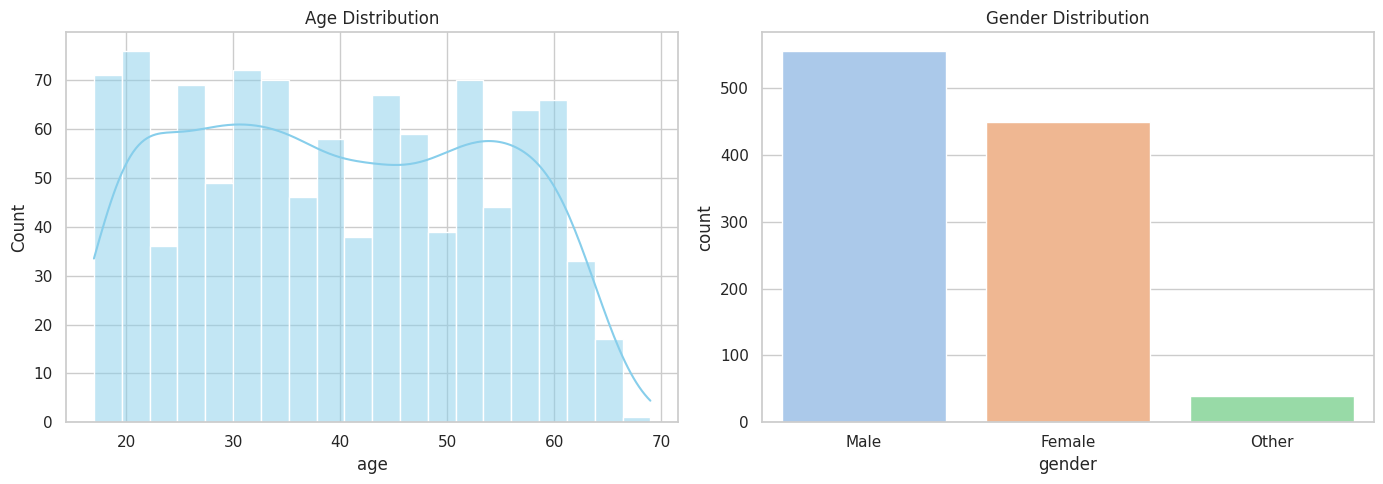

In [6]:
# Age & Gender Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if 'age' in df.columns:
    sns.histplot(data=df, x='age', bins=20, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Age Distribution')

if 'gender' in df.columns:
    sns.countplot(data=df, x='gender', ax=axes[1], palette='pastel')
    axes[1].set_title('Gender Distribution')
plt.tight_layout()
plt.show()

# Self-Reported Investment Confidence
if 'investment_confidence_level' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, y='investment_confidence_level',
                  order=df['investment_confidence_level'].value_counts().index, palette='magma')
    plt.title('Self-Reported Investment Confidence')
    plt.show()

Bivariate Analysis (Budgeting & Spending Behaviors)

In [8]:
# Budgeting Adherence vs. Impulse Purchase Frequency
if 'impulse_purchase_frequency' in df.columns and 'follows_monthly_budget' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='impulse_purchase_frequency', hue='follows_monthly_budget',
                  order=['Never', 'Rarely', 'Sometimes', 'Often', 'Very Often'], palette='Set2')
    plt.title('Impact of Budgeting on Impulse Purchasing')
    plt.xlabel('Impulse Purchase Frequency')
    plt.ylabel('Count')
    plt.legend(title='Follows Budget')
    plt.show()

Encoding and Feature Matrix

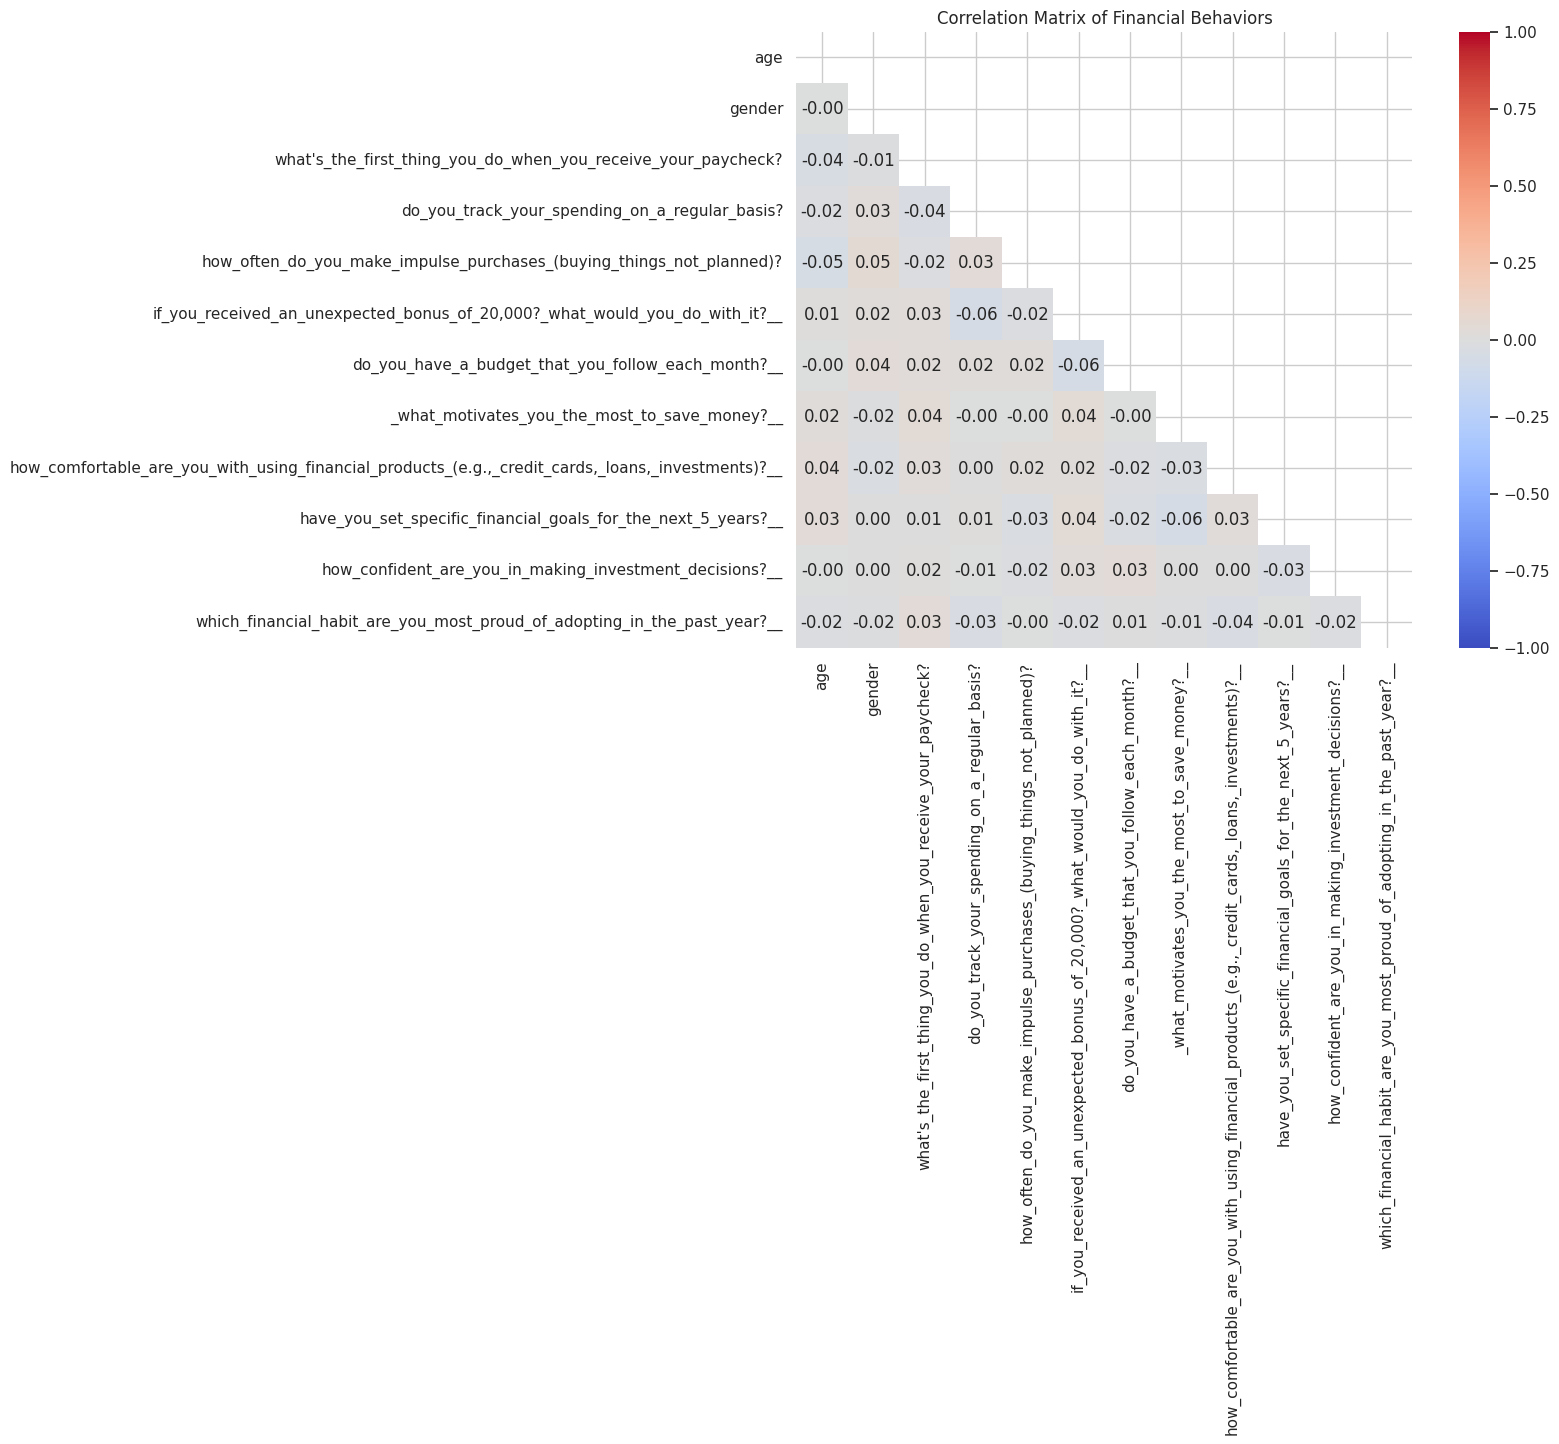

In [9]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Ordinal Encoding for ranked variables (customize these keys based on your exact dataset columns)
impulse_mapping = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Very Often': 4}
if 'impulse_purchase_frequency' in df_encoded.columns:
    df_encoded['impulse_purchase_frequency'] = df_encoded['impulse_purchase_frequency'].map(impulse_mapping)

# Label Encoding for remaining categorical variables
le = LabelEncoder()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Plot Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Financial Behaviors')
plt.show()

Machine Learning Preparation

In [10]:
# Isolate target variable from predictor features
# Update 'follows_monthly_budget' to whichever variable you are trying to classify
target_col = 'follows_monthly_budget'

if target_col in df_encoded.columns:
    X = df_encoded.drop(target_col, axis=1)
    y = df_encoded[target_col]

    print(f"Features (X) shape: {X.shape}")
    print(f"Target (y) shape: {y.shape}")
    print("\nData is successfully prepared for the classification models!")
else:
    print(f"Target column '{target_col}' not found. Please update target_col variable.")

Target column 'follows_monthly_budget' not found. Please update target_col variable.
